In [3]:
# Loading 
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from sympy import symbols, diff, solve, lambdify
from sympy.physics.quantum.tensorproduct import TensorProduct
# Define the variable and the function
ri = symbols('ri')
phi = symbols('phi')
lbd = symbols('lbd')
R = symbols('R')
p = symbols('p')


In [4]:
# Initialize the parameters
L = 0.05
R_i = 0.00035
R_o = 0.0023
Theta = 0
alpha = 1.44
mu_1 = 427560
mu_2 = 8500000
P = np.linspace(0, 1000000, 100)  # Pressure range from 0 to 100 kPa

In [5]:
# Define the function f(ri, phi, R, lambda) using sympy
# Deformation gradient tensor
r = sp.sqrt((R**2-R_i**2)/lbd + ri**2)
F = sp.Matrix([[R/(r*lbd), 0, 0], [0, r/R, r*phi/L], [0, 0, lbd]])
S = sp.Matrix([[0], [sp.sin(alpha)], [sp.cos(alpha)]])
print("Deformation Gradient Tensor F:")
sp.pprint(F)
print("\nDirection Vector s:")
sp.pprint(S)
# Calculate the Cauchy-Green deformation tensor C
s = F * S
sp.pprint(s)

Deformation Gradient Tensor F:
⎡              R                                                               ↪
⎢──────────────────────────────              0                               0 ↪
⎢         _____________________                                                ↪
⎢        ╱        2                                                            ↪
⎢       ╱    2   R  - 1.225e-7                                                 ↪
⎢lbd⋅  ╱   ri  + ─────────────                                                 ↪
⎢    ╲╱               lbd                                                      ↪
⎢                                                                              ↪
⎢                                     _____________________                    ↪
⎢                                    ╱        2                                ↪
⎢                                   ╱    2   R  - 1.225e-7               _____ ↪
⎢                                  ╱   ri  + ─────────────              ╱     

In [6]:
# First and fourth invariants of C
I1 = sp.trace(sp.MatMul(F, F.T))
I4 = sp.MatMul(s.T, s)
print(sp.shape(I4))   
I4 = I4[0,0]
sp.pprint(I4)

(1, 1)
                                                                               ↪
                          ⎛                                                    ↪
                          ⎜                                                    ↪
                          ⎜                        _____________________       ↪
                          ⎜                       ╱        2               0.9 ↪
                      2   ⎜                      ╱    2   R  - 1.225e-7        ↪
0.0170103438010126⋅lbd  + ⎜2.60847417476291⋅φ⋅  ╱   ri  + ─────────────  + ─── ↪
                          ⎝                   ╲╱               lbd             ↪

↪                                           2
↪                     _____________________⎞ 
↪                    ╱        2            ⎟ 
↪                   ╱    2   R  - 1.225e-7 ⎟ 
↪ 91458348191686⋅  ╱   ri  + ───────────── ⎟ 
↪                ╲╱               lbd      ⎟ 
↪ ─────────────────────────────────────────⎟ 
↪                   R 

In [7]:
sigma_tube = mu_1 * sp.MatMul(F, F.T) 
sigma_coil = mu_2 * TensorProduct(s, s.T) * (sp.sqrt(I4) - 1) / sp.sqrt(I4) 
sigma_total = sigma_tube + sigma_coil - (p * sp.eye(3))
sp.shape(sigma_total)

sp.pprint(sigma_total[0,0])

                2             
        427560⋅R              
────────────────────────── - p
     ⎛       2           ⎞    
   2 ⎜  2   R  - 1.225e-7⎟    
lbd ⋅⎜ri  + ─────────────⎟    
     ⎝           lbd     ⎠    


In [20]:
f_pressure = R / (R**2 - R_i**2 + lbd*ri**2) * (sigma_total[1,1] - sigma_total[0,0])
df_pressure_dri = diff(f_pressure, ri)
df_pressure_dphi = diff(f_pressure, phi)
df_pressure_dlbd = diff(f_pressure, lbd)
f_load = np.pi * R/lbd * (2 * sigma_total[2,2] - sigma_total[0,0] - sigma_total[1,1])
df_load_dri = diff(f_load, ri)
df_load_phi = diff(f_load, phi)
df_load_dlbd = diff(f_load, lbd)
f_moment = sigma_total[1,2] * r * R / lbd * 2 * np.pi
df_moment_dri = diff(f_moment, ri)
df_moment_dphi = diff(f_moment, phi)
df_moment_dlbd = diff(f_moment, lbd)


In [57]:
# Initialize values for Newton-Raphson method
lbd_init = 1.5
phi_init = 0.5
ri_init = 0.0005
subs_init = {lbd: lbd_init, phi: phi_init, ri: ri_init}
tolerance = 1e-6
max_iterations = 100


In [58]:
# Numerical evaluation of the integrals
def numerical_integral(func, x_start, x_end, num_points=100):
    x_values = np.linspace(x_start, x_end, num_points)
    y_values = np.array([func.subs(R, x).evalf() for x in x_values])
    integral = np.sum(y_values) * (x_end - x_start) / num_points
    return integral


In [ ]:
# analytical integral for pressure and load and moment
def Jacobian_matrix(f_pressure, f_load, f_moment, df_pressure_dri, df_pressure_dphi, df_pressure_dlbd,
                    df_load_dri, df_load_phi, df_load_dlbd, df_moment_dri, df_moment_dphi, df_moment_dlbd,
                    ri_val, phi_val, lbd_val, R_i, R_o, P):

    subs_val = [(ri, ri_val), (phi, phi_val), (lbd, lbd_val)]
    f_pressure_subs = f_pressure.subs(subs_val)
    f_load_subs = f_load.subs(subs_val)
    f_moment_subs = f_moment.subs(subs_val)
    df_pressure_dri_subs = df_pressure_dri.subs(subs_val)
    df_pressure_dphi_subs = df_pressure_dphi.subs(subs_val)
    df_pressure_dlbd_subs = df_pressure_dlbd.subs(subs_val)
    df_load_dri_subs  = df_load_dri.subs(subs_val)
    df_load_dphi_subs = df_load_phi.subs(subs_val)
    df_load_dlbd_subs = df_load_dlbd.subs(subs_val)
    df_moment_dri_subs = df_moment_dri.subs(subs_val)
    df_moment_dphi_subs = df_moment_dphi.subs(subs_val)
    df_moment_dlbd_subs = df_moment_dlbd.subs(subs_val)
    # seperate into thread into threads to speed up the computation of the integrals
    
    f_pressure_integral = numerical_integral(f_pressure_subs, R_i, R_o) - P
    f_load_integral = numerical_integral(f_load_subs, R_i, R_o)
    f_moment_integral = numerical_integral(f_moment_subs, R_i, R_o)
    df_pressure_dri_integral = numerical_integral(df_pressure_dri_subs, R_i, R_o)
    df_pressure_dphi_integral = numerical_integral(df_pressure_dphi_subs, R_i, R_o)
    df_pressure_dlbd_integral = numerical_integral(df_pressure_dlbd_subs, R_i, R_o)
    df_load_dri_integral = numerical_integral(df_load_dri_subs, R_i, R_o)
    df_load_dphi_integral = numerical_integral(df_load_dphi_subs, R_i, R_o)
    df_load_dlbd_integral = numerical_integral(df_load_dlbd_subs, R_i, R_o)
    df_moment_dri_integral = numerical_integral(df_moment_dri_subs, R_i, R_o)
    df_moment_dphi_integral = numerical_integral(df_moment_dphi_subs, R_i, R_o)
    df_moment_dlbd_integral = numerical_integral(df_moment_dlbd_subs, R_i, R_o)         

    J = np.array([[df_pressure_dri_integral, df_pressure_dphi_integral, df_pressure_dlbd_integral],
                [df_load_dri_integral, df_load_dphi_integral, df_load_dlbd_integral],
                [df_moment_dri_integral, df_moment_dphi_integral, df_moment_dlbd_integral]], dtype=np.float64)
    
    return J, f_pressure_integral, f_load_integral, f_moment_integral


J, f_pressure_integral, f_load_integral, f_moment_integral = Jacobian_matrix(f_pressure, f_load, f_moment, df_pressure_dri, df_pressure_dphi, df_pressure_dlbd,
                                                                            df_load_dri, df_load_phi, df_load_dlbd, df_moment_dri, df_moment_dphi, df_moment_dlbd,
                                                                            ri_init, phi_init, lbd_init, R_i, R_o, P)

# Newton-Raphson iteration
def newton_raphson(f_pressure, f_load, f_moment, df_pressure_dri, df_pressure_dphi, df_pressure_dlbd,
                    df_load_dri, df_load_phi, df_load_dlbd, df_moment_dri, df_moment_dphi, df_moment_dlbd,
                    ri_val, phi_val, lbd_val, R_i, R_o, P, lr, max_iterations, tolerance):

    x = np.array([ri_init, phi_init, lbd_init], dtype=np.float64)
    f_pressure_history = []
    f_load_history = []
    f_moment_history = []
    for i in range(max_iterations):
        ri_val, phi_val, lbd_val = x
        J, f_pressure_integral, f_load_integral, f_moment_integral = Jacobian_matrix(f_pressure, f_load, f_moment, df_pressure_dri, df_pressure_dphi, df_pressure_dlbd,
                                                                            df_load_dri, df_load_phi, df_load_dlbd, df_moment_dri, df_moment_dphi, df_moment_dlbd,
                                                                            ri_val, phi_val, lbd_val, R_i, R_o, P)
        F = np.array([f_pressure_integral, f_load_integral, f_moment_integral], dtype=np.float64)
        f_pressure_history.append(f_pressure_integral)
        f_load_history.append(f_load_integral)
        f_moment_history.append(f_moment_integral)
        delta = -np.dot(np.linalg.inv(J), F)
        x += lr * delta
        # Display the current iteration and the values of ri, phi, lambda
        print(f"Iteration {i+1}: ri = {x[0]}, phi = {x[1]}, lambda = {x[2]}")
        if np.linalg.norm(delta) < tolerance:
            print(f"Convergence achieved after {i+1} iterations.")
            break
    return x, f_pressure_history, f_load_history, f_moment_history

Iteration 1: ri = 0.0004976279643067714, phi = 0.45389101191781317, lambda = 1.459035587505019
Iteration 2: ri = 0.0004953367900783853, phi = 0.4060019208509155, lambda = 1.4231019001038292
Iteration 3: ri = 0.0004931606051942889, phi = 0.35882228587381554, lambda = 1.3914173020643277
Iteration 4: ri = 0.0004911161185749479, phi = 0.3137893047852108, lambda = 1.363336724689488
Iteration 5: ri = 0.0004892090656190784, phi = 0.2716684366001249, lambda = 1.3383284165224498
Iteration 6: ri = 0.0004874384718049764, phi = 0.23280283302412363, lambda = 1.3159533827803411
Iteration 7: ri = 0.00048579942517936, phi = 0.19727528471299333, lambda = 1.2958480234619438
Iteration 8: ri = 0.00048428485399585887, phi = 0.16501262851066512, lambda = 1.2777098627188936
Iteration 9: ri = 0.00048288665048770496, phi = 0.13585261326707676, lambda = 1.2612859989338994
Iteration 10: ri = 0.00048159636903804994, phi = 0.10958637828694795, lambda = 1.246363832927363
Iteration 11: ri = 0.00048040564926259973, p

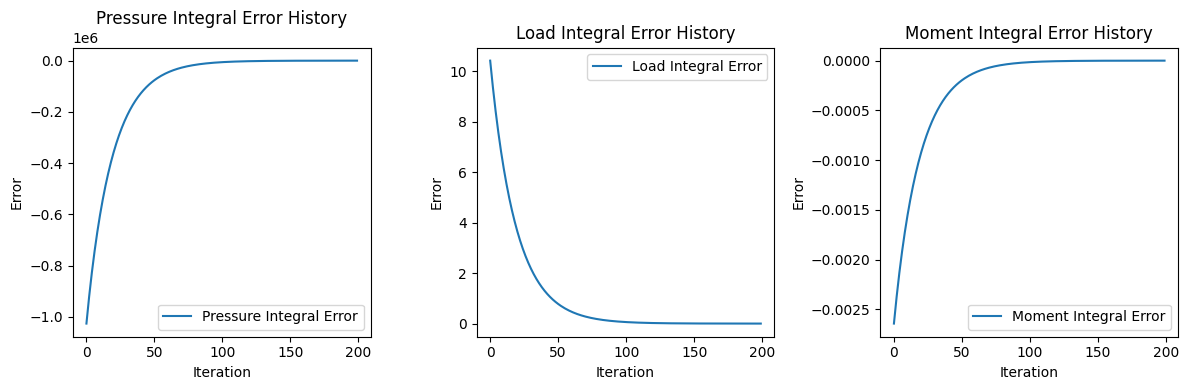

In [64]:
P =1200000  # Example pressure value for testing
solution, f_pressure_history, f_load_history, f_moment_history = newton_raphson(f_pressure, f_load, f_moment, df_pressure_dri, df_pressure_dphi, df_pressure_dlbd,
                                                                            df_load_dri, df_load_phi, df_load_dlbd, df_moment_dri, df_moment_dphi, df_moment_dlbd,
                                                                            ri_init, phi_init, lbd_init, R_i, R_o, P, lr=0.05, max_iterations=200, tolerance=1e-6)
ri_solution, phi_solution, lbd_solution = solution
print(f"Solution: ri = {ri_solution}, phi = {phi_solution}, lambda = {lbd_solution}")
# plot error history of pressure, load and moment
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(f_pressure_history, label='Pressure Integral Error')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Pressure Integral Error History')
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(f_load_history, label='Load Integral Error')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Load Integral Error History')
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(f_moment_history, label='Moment Integral Error')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Moment Integral Error History')
plt.legend()
plt.tight_layout()
plt.show()